# Clasificación de imágenes en Imagenette: vectorización y reducción de la dimensionalidad de características

## Objetivo

Este cuadernillo construye, paso a paso, un pipeline completo de clasificación de imágenes sobre el dataset **Imagenette** cumpliendo los siguientes requisitos:

1. Trabajar con imágenes de **más de 200 px** de lado.
2. **Vectorizar** las imágenes (convertirlas en vectores de características).
3. **Aplicar y explicar métodos** para evitar que esos vectores de características sean demasiado grandes (reducción de la dimensionalidad).
4. **Entrenar una red neuronal** sobre las características resultantes, implementando el pipeline mediante **clases** (diseño orientado a objetos).

## Estructura del cuadernillo

1. El dataset Imagenette
2. Verificación del tamaño de las imágenes (> 200 px)
3. Vectorización de imágenes
4. El problema de la alta dimensionalidad
5. Métodos para reducir la dimensionalidad de las características
6. Diseño orientado a objetos: las clases del proyecto
7. Preparación de los datos usando las clases
8. Entrenamiento con características reducidas por PCA
9. Entrenamiento con características extraídas por una CNN preentrenada
10. Evaluación y comparación de resultados
11. Conclusiones

> **Nota sobre tiempos de ejecución:** la descarga del dataset (~325 MB) y la extracción de características con la CNN preentrenada sobre el dataset completo pueden tardar varios minutos en un equipo sin GPU. Se incluye un parámetro `MAX_POR_CLASE` para hacer pruebas rápidas con un subconjunto antes de correr todo el pipeline completo.


In [1]:
# Si hace falta, instalar dependencias (descomentar la siguiente línea)
#!pip install torch torchvision scikit-learn matplotlib seaborn pandas pillow

import os
import time
import random
from pathlib import Path
from abc import ABC, abstractmethod

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torchvision
import torchvision.transforms as T
import torchvision.models as models
from torchvision.datasets import Imagenette

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Reproducibilidad
SEMILLA = 42
random.seed(SEMILLA)
np.random.seed(SEMILLA)
torch.manual_seed(SEMILLA)

# Dispositivo de cómputo (usa GPU si está disponible)
DISPOSITIVO = "cuda" if torch.cuda.is_available() else "cpu"
print("Dispositivo utilizado:", DISPOSITIVO)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

# Directorio donde se descargará/leerá el dataset
DATA_DIR = Path("./datos_imagenette")
DATA_DIR.mkdir(exist_ok=True)

# Parámetro para pruebas rápidas: limita la cantidad de imágenes por clase.
# Poner en None para usar el dataset completo.
MAX_POR_CLASE = None   # p. ej. usar 300 para iterar rápido durante el desarrollo


Dispositivo utilizado: cuda


## 1. El dataset Imagenette

**Imagenette** es un subconjunto de 10 clases fáciles de distinguir extraídas de ImageNet, publicado por fast.ai. Es mucho más liviano que ImageNet completo, lo que lo hace apropiado para experimentar con pipelines completos de clasificación sin necesitar horas de descarga ni de entrenamiento.

Las 10 clases son:

| WNID | Clase (inglés) | Clase (español) |
|---|---|---|
| n01440764 | tench | tenca (pez) |
| n02102040 | English springer | springer spaniel inglés (perro) |
| n02979186 | cassette player | reproductor de casetes |
| n03000684 | chain saw | motosierra |
| n03028079 | church | iglesia |
| n03394916 | French horn | trompa (instrumento) |
| n03417042 | garbage truck | camión de basura |
| n03425413 | gas pump | surtidor de gasolina |
| n03445777 | golf ball | pelota de golf |
| n03888257 | parachute | paracaídas |

El dataset está disponible en tres resoluciones:

- **`full`**: tamaño original (varios GB).
- **`320px`**: el lado más corto redimensionado a 320 px.
- **`160px`**: el lado más corto redimensionado a 160 px.

Como el requisito de este trabajo es usar **imágenes mayores a 200 px**, la versión `160px` queda descartada (160 < 200). Usaremos la versión **`320px`**: garantiza que el lado más corto de cada imagen sea de 320 px (> 200 px) y su descarga (~325 MB) es mucho más manejable que la versión `full`.


In [2]:
TAMANO_DESCARGA = "320px"   # opciones válidas para respetar el requisito >200px: "320px" o "full"

# torchvision.datasets.Imagenette descarga y extrae automáticamente el .tgz oficial de fast.ai
inicio = time.time()
ds_train_tv = Imagenette(root=DATA_DIR, split="train", size=TAMANO_DESCARGA, download=True)
ds_val_tv = Imagenette(root=DATA_DIR, split="val", size=TAMANO_DESCARGA, download=True)
print(f"Descarga/verificación completada en {time.time()-inicio:.1f} s")

print(f"Imágenes de entrenamiento: {len(ds_train_tv)}")
print(f"Imágenes de validación:    {len(ds_val_tv)}")
print("Clases:", [c[0] for c in ds_train_tv.classes])

# Carpeta raíz donde quedaron extraídas las imágenes (train/<wnid>/*.JPEG, val/<wnid>/*.JPEG)
nombre_carpeta = "imagenette2" if TAMANO_DESCARGA == "full" else f"imagenette2-{TAMANO_DESCARGA.replace('px', '')}"
RAIZ_DATOS = DATA_DIR / nombre_carpeta
print("Carpeta del dataset:", RAIZ_DATOS)


100.0%


Descarga/verificación completada en 63.5 s
Imágenes de entrenamiento: 9469
Imágenes de validación:    3925
Clases: ['tench', 'English springer', 'cassette player', 'chain saw', 'church', 'French horn', 'garbage truck', 'gas pump', 'golf ball', 'parachute']
Carpeta del dataset: datos_imagenette\imagenette2-320


{0: 'tenca', 1: 'springer spaniel', 2: 'reproductor de casetes', 3: 'motosierra', 4: 'iglesia', 5: 'trompa', 6: 'camion de basura', 7: 'surtidor de gasolina', 8: 'pelota de golf', 9: 'paracaidas'}


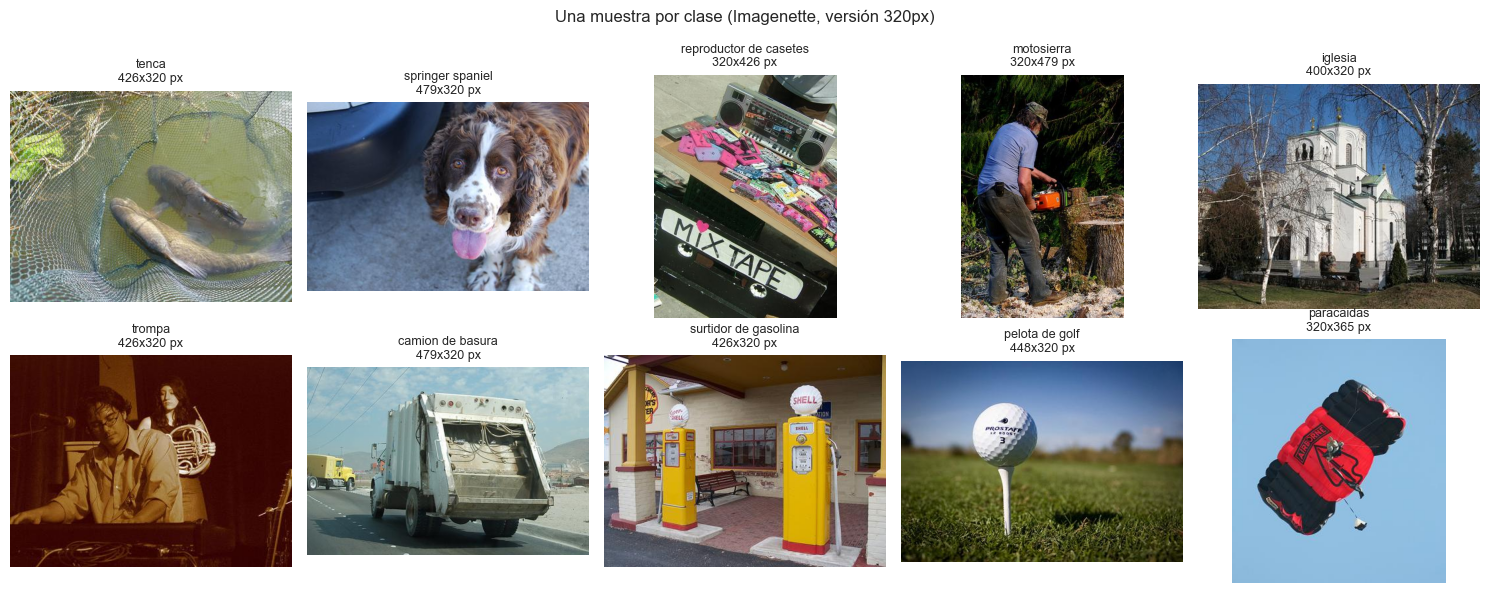

In [3]:
# Diccionario WNID -> nombre de clase legible (en español), usado en todo el cuadernillo
NOMBRES_CLASES = {
    "n01440764": "tenca",
    "n02102040": "springer spaniel",
    "n02979186": "reproductor de casetes",
    "n03000684": "motosierra",
    "n03028079": "iglesia",
    "n03394916": "trompa",
    "n03417042": "camion de basura",
    "n03425413": "surtidor de gasolina",
    "n03445777": "pelota de golf",
    "n03888257": "paracaidas",
}
WNIDS_ORDENADOS = sorted(NOMBRES_CLASES.keys())          # mismo criterio que ImageFolder (orden alfabético)
WNID_A_IDX = {w: i for i, w in enumerate(WNIDS_ORDENADOS)}
IDX_A_NOMBRE = {i: NOMBRES_CLASES[w] for w, i in WNID_A_IDX.items()}
N_CLASES = len(WNIDS_ORDENADOS)
print(IDX_A_NOMBRE)

# Cuadrícula de imágenes de muestra, una por clase
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, wnid in zip(axes.flat, WNIDS_ORDENADOS):
    carpeta_clase = RAIZ_DATOS / "train" / wnid
    archivo = next(carpeta_clase.glob("*.JPEG"))
    img = Image.open(archivo)
    ax.imshow(img)
    ax.set_title(f"{NOMBRES_CLASES[wnid]}\n{img.size[0]}x{img.size[1]} px", fontsize=9)
    ax.axis("off")
plt.suptitle("Una muestra por clase (Imagenette, versión 320px)")
plt.tight_layout()
plt.show()


## 2. Verificación del tamaño de las imágenes (> 200 px)

Aunque la versión `320px` de Imagenette garantiza por construcción que el lado más corto de cada imagen es de 320 px, en este trabajo implementamos una función general de verificación/filtrado. Esto permite:

- Confirmar explícitamente que **todas** las imágenes usadas cumplen el requisito de más de 200 px.
- Reutilizar la misma función con otras fuentes de imágenes (por ejemplo la versión `full`, que sí puede contener imágenes heterogéneas) donde el filtro no sería trivial.


In [4]:
def filtrar_imagenes_por_tamano(carpeta_split, tamano_minimo=200, max_por_clase=None,
                                 extensiones=(".jpeg", ".jpg", ".png")):
    '''
    Recorre `carpeta_split` (estructura <carpeta_split>/<wnid>/*.ext), y devuelve
    una lista de tuplas (ruta_absoluta, wnid) para las imágenes cuyo lado más
    corto es mayor o igual a `tamano_minimo` píxeles.
    '''
    rutas_validas = []
    descartadas = 0
    for wnid in sorted(os.listdir(carpeta_split)):
        carpeta_clase = Path(carpeta_split) / wnid
        if not carpeta_clase.is_dir():
            continue
        contador_clase = 0
        for archivo in sorted(os.listdir(carpeta_clase)):
            if not archivo.lower().endswith(extensiones):
                continue
            ruta = carpeta_clase / archivo
            try:
                with Image.open(ruta) as img:
                    ancho, alto = img.size
            except Exception:
                descartadas += 1
                continue
            if min(ancho, alto) >= tamano_minimo:
                rutas_validas.append((str(ruta), wnid))
                contador_clase += 1
                if max_por_clase is not None and contador_clase >= max_por_clase:
                    break
            else:
                descartadas += 1
    return rutas_validas, descartadas


inicio = time.time()
rutas_train, descartadas_train = filtrar_imagenes_por_tamano(
    RAIZ_DATOS / "train", tamano_minimo=200, max_por_clase=MAX_POR_CLASE)
rutas_val, descartadas_val = filtrar_imagenes_por_tamano(
    RAIZ_DATOS / "val", tamano_minimo=200, max_por_clase=MAX_POR_CLASE)
print(f"Verificación completada en {time.time()-inicio:.1f} s")

print(f"Entrenamiento -> válidas: {len(rutas_train)}, descartadas (<200px): {descartadas_train}")
print(f"Validación     -> válidas: {len(rutas_val)}, descartadas (<200px): {descartadas_val}")


Verificación completada en 1.5 s
Entrenamiento -> válidas: 9469, descartadas (<200px): 0
Validación     -> válidas: 3925, descartadas (<200px): 0


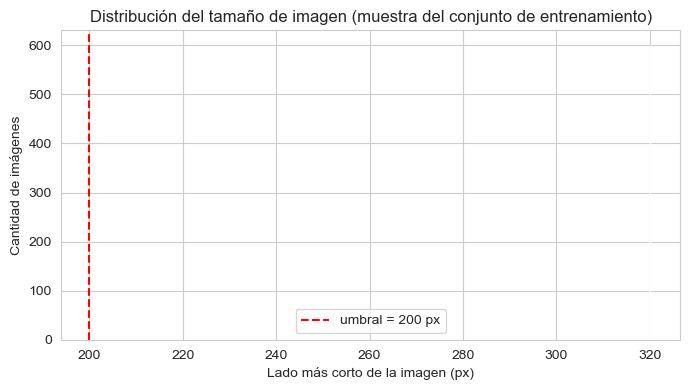

In [5]:
# Histograma del lado más corto de una muestra de imágenes, para visualizar la distribución de tamaños
muestra = random.sample(rutas_train, min(600, len(rutas_train)))
lados_cortos = []
for ruta, _ in muestra:
    with Image.open(ruta) as img:
        lados_cortos.append(min(img.size))

plt.figure(figsize=(7, 4))
sns.histplot(lados_cortos, bins=20, color="steelblue")
plt.axvline(200, color="red", linestyle="--", label="umbral = 200 px")
plt.xlabel("Lado más corto de la imagen (px)")
plt.ylabel("Cantidad de imágenes")
plt.title("Distribución del tamaño de imagen (muestra del conjunto de entrenamiento)")
plt.legend()
plt.tight_layout()
plt.show()


## 3. Vectorización de imágenes

**Vectorizar** una imagen significa transformar su representación natural, una matriz de píxeles con 2 o 3 dimensiones (alto × ancho × canales de color), en un **vector unidimensional** de números, de forma que pueda usarse como entrada de modelos clásicos de aprendizaje automático (los cuales, en general, esperan un vector de características por muestra, no una estructura matricial).

El procedimiento típico es:

1. Redimensionar la imagen a un tamaño fijo (todas las muestras deben tener la misma cantidad de características).
2. Convertir la imagen a un arreglo numérico (`alto × ancho × canales`).
3. "Aplanar" (`flatten`) ese arreglo a un vector de una sola dimensión.
4. Normalizar los valores (por ejemplo, dividir por 255 para llevarlos al rango [0, 1]).


In [6]:
def vectorizar_imagen(ruta, tamano=(200, 200), escala_grises=False):
    '''Redimensiona, normaliza y aplana una imagen en un vector 1D.'''
    modo = "L" if escala_grises else "RGB"
    img = Image.open(ruta).convert(modo).resize(tamano)
    arreglo = np.asarray(img, dtype=np.float32) / 255.0
    return arreglo.flatten()

# Demostración sobre una imagen real del dataset, redimensionada exactamente a 200x200 (nuestro tamaño mínimo requerido)
ruta_ejemplo, wnid_ejemplo = rutas_train[0]
vector_ejemplo = vectorizar_imagen(ruta_ejemplo, tamano=(200, 200), escala_grises=False)

print(f"Imagen de ejemplo: clase '{NOMBRES_CLASES[wnid_ejemplo]}'")
print(f"Forma como imagen redimensionada: 200 x 200 x 3 canales")
print(f"Forma como vector: {vector_ejemplo.shape}  ->  {vector_ejemplo.shape[0]:,} características por imagen")


Imagen de ejemplo: clase 'tenca'
Forma como imagen redimensionada: 200 x 200 x 3 canales
Forma como vector: (120000,)  ->  120,000 características por imagen


## 4. El problema de la alta dimensionalidad ("maldición de la dimensionalidad")

El resultado anterior muestra el problema central de este trabajo: **vectorizar una sola imagen de apenas 200×200 px en color ya produce 120 000 características**. Esto trae varias consecuencias negativas, conocidas en conjunto como la *maldición de la dimensionalidad*:

- **Costo computacional y de memoria**: una matriz de entrenamiento de N imágenes tiene forma `N × 120 000`. Con unos pocos miles de imágenes, esto ya ocupa varios gigabytes en memoria (float32).
- **Sobreajuste (overfitting)**: cuando el número de características es comparable o mayor al número de muestras de entrenamiento, los modelos tienen "demasiados grados de libertad" y tienden a memorizar en lugar de generalizar.
- **Redundancia**: los píxeles vecinos de una imagen están altamente correlacionados (una porción de cielo azul tiene miles de píxeles casi idénticos); gran parte de esas 120 000 características aporta información redundante, no independiente.
- **Distancias poco informativas**: en espacios de muy alta dimensión, las nociones de "cercanía" que usan muchos algoritmos (KNN, clustering, SVM con kernels basados en distancia) pierden poder discriminativo, ya que todos los puntos tienden a parecer igual de "lejanos" entre sí.

La siguiente tabla ilustra cómo crece el problema según la resolución elegida al vectorizar, comparado con la cantidad de imágenes de entrenamiento disponibles:


In [7]:
resoluciones = [(64, 64), (100, 100), (150, 150), (200, 200)]
filas = []
for w, h in resoluciones:
    dim_gris = w * h
    dim_rgb = w * h * 3
    filas.append({
        "Resolucion": f"{w}x{h}",
        "Dim. escala de grises": f"{dim_gris:,}",
        "Dim. RGB": f"{dim_rgb:,}",
        "Muestras de entrenamiento": f"{len(rutas_train):,}",
        "Caracteristicas RGB > muestras?": "Si" if dim_rgb > len(rutas_train) else "No",
    })
pd.DataFrame(filas)


,Resolucion,Dim. escala de grises,Dim. RGB,Muestras de entrenamiento,Caracteristicas RGB > muestras?
0,64x64,"4,096","12,288","9,469",Si
1,100x100,"10,000","30,000","9,469",Si
2,150x150,"22,500","67,500","9,469",Si
3,200x200,"40,000","120,000","9,469",Si


## 5. Métodos para reducir la dimensionalidad de las características

En esta sección se explican y aplican, de forma progresiva, cuatro estrategias para evitar que el vector de características sea excesivamente grande:

1. Redimensionamiento controlado (bajar la resolución antes de vectorizar).
2. Conversión a escala de grises.
3. PCA (Análisis de Componentes Principales).
4. Extracción de características con una CNN preentrenada (transfer learning).

Las dos primeras son simples y directas; las dos últimas son las que se integrarán en las clases del pipeline final (secciones 6 en adelante).


### 5.1 Redimensionamiento controlado

Es el método más simple: en lugar de vectorizar a la resolución original (o a 200×200), se reduce el tamaño de la imagen antes de aplanarla. El costo es perder detalle fino; el beneficio es una reducción **cuadrática** de la cantidad de características (reducir el lado a la mitad reduce las características a un cuarto).


In [8]:
for tam in [(200, 200), (100, 100), (64, 64), (32, 32)]:
    v = vectorizar_imagen(ruta_ejemplo, tamano=tam, escala_grises=False)
    print(f"Redimensionado a {tam[0]}x{tam[1]} (RGB) -> vector de {v.shape[0]:,} caracteristicas")


Redimensionado a 200x200 (RGB) -> vector de 120,000 caracteristicas
Redimensionado a 100x100 (RGB) -> vector de 30,000 caracteristicas
Redimensionado a 64x64 (RGB) -> vector de 12,288 caracteristicas
Redimensionado a 32x32 (RGB) -> vector de 3,072 caracteristicas


### 5.2 Conversión a escala de grises

Convertir de RGB (3 canales) a escala de grises (1 canal) reduce la cantidad de características a la tercera parte, a costa de perder la información de color. Suele combinarse con el redimensionamiento del punto anterior.


In [9]:
v_rgb = vectorizar_imagen(ruta_ejemplo, tamano=(100, 100), escala_grises=False)
v_gris = vectorizar_imagen(ruta_ejemplo, tamano=(100, 100), escala_grises=True)
print(f"100x100 RGB           -> {v_rgb.shape[0]:,} caracteristicas")
print(f"100x100 escala grises -> {v_gris.shape[0]:,} caracteristicas  (reduccion de {v_rgb.shape[0]/v_gris.shape[0]:.0f}x)")


100x100 RGB           -> 30,000 caracteristicas
100x100 escala grises -> 10,000 caracteristicas  (reduccion de 3x)


### 5.3 PCA (Análisis de Componentes Principales)

PCA es una técnica estadística que encuentra un nuevo sistema de ejes (las **componentes principales**), ortogonales entre sí, ordenados de manera que el primero capta la mayor varianza posible de los datos, el segundo la mayor varianza restante, y así sucesivamente.

En la práctica, para reducir la dimensionalidad:

1. Se **estandarizan** los datos (media 0, desviación estándar 1 en cada característica); esto es necesario porque PCA es sensible a la escala de las variables.
2. Se calculan las componentes principales sobre el conjunto de entrenamiento.
3. Se conservan solo las primeras *k* componentes, eligiendo *k* de forma que se retenga un porcentaje alto de la varianza total (por ejemplo, 95%).
4. Cada imagen se proyecta a ese espacio de *k* dimensiones, muy inferior a la dimensión original.

A diferencia del redimensionamiento simple, PCA aprovecha la **redundancia estadística** entre píxeles (correlaciones) del conjunto de datos completo para decidir qué combinaciones de píxeles son más informativas, en lugar de simplemente descartar resolución de forma fija.

A continuación se muestra una demostración sobre una pequeña muestra: cuánta varianza se retiene según el número de componentes, y cómo se ve una imagen reconstruida a partir de un número reducido de componentes.


Matriz de la muestra de demostracion: (100, 4096)


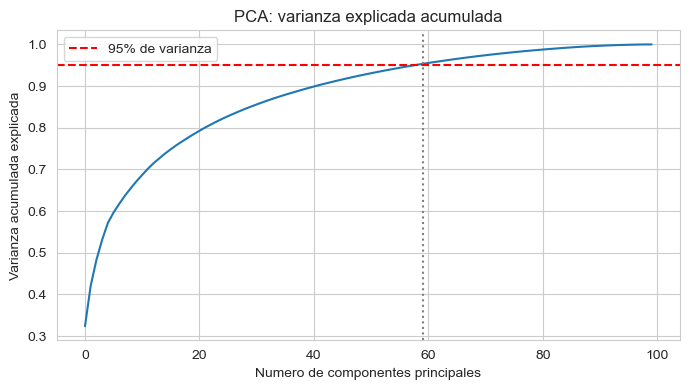

Se necesitan 59 componentes (de 4096) para retener el 95% de la varianza en esta muestra


In [10]:
# Demostracion de PCA sobre una pequeña muestra (100 imagenes, escala de grises 64x64 = 4096 caracteristicas)
muestra_demo = random.sample(rutas_train, 100)
X_demo = np.stack([vectorizar_imagen(r, tamano=(64, 64), escala_grises=True) for r, _ in muestra_demo])
print("Matriz de la muestra de demostracion:", X_demo.shape)

escalador_demo = StandardScaler().fit(X_demo)
X_demo_esc = escalador_demo.transform(X_demo)

pca_demo = PCA().fit(X_demo_esc)
varianza_acumulada = np.cumsum(pca_demo.explained_variance_ratio_)

plt.figure(figsize=(7, 4))
plt.plot(varianza_acumulada)
plt.axhline(0.95, color="red", linestyle="--", label="95% de varianza")
n_para_95 = int(np.argmax(varianza_acumulada >= 0.95)) + 1
plt.axvline(n_para_95, color="gray", linestyle=":")
plt.xlabel("Numero de componentes principales")
plt.ylabel("Varianza acumulada explicada")
plt.title("PCA: varianza explicada acumulada")
plt.legend()
plt.tight_layout()
plt.show()
print(f"Se necesitan {n_para_95} componentes (de {X_demo.shape[1]}) para retener el 95% de la varianza en esta muestra")


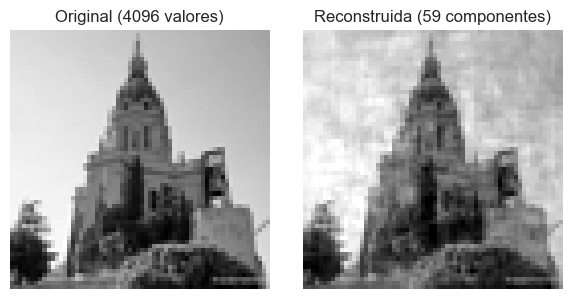

In [11]:
# Reconstruccion aproximada de una imagen a partir de sus componentes principales, para visualizar la perdida de informacion
pca_reconstruccion = PCA(n_components=n_para_95).fit(X_demo_esc)
X_demo_reducido = pca_reconstruccion.transform(X_demo_esc)
X_demo_reconstruido = escalador_demo.inverse_transform(pca_reconstruccion.inverse_transform(X_demo_reducido))

idx_muestra = 0
original = X_demo[idx_muestra].reshape(64, 64)
reconstruida = np.clip(X_demo_reconstruido[idx_muestra].reshape(64, 64), 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(original, cmap="gray"); axes[0].set_title("Original (4096 valores)"); axes[0].axis("off")
axes[1].imshow(reconstruida, cmap="gray"); axes[1].set_title(f"Reconstruida ({n_para_95} componentes)"); axes[1].axis("off")
plt.tight_layout()
plt.show()


### 5.4 Extracción de características con una CNN preentrenada (transfer learning)

En lugar de reducir estadísticamente el vector de píxeles crudos, este método usa una **red neuronal convolucional ya entrenada** sobre un problema de clasificación de imágenes a gran escala (ImageNet, más de un millón de imágenes) como **extractor de características**.

La idea:

1. Se toma una arquitectura conocida (aquí, **ResNet-18**) con sus pesos ya entrenados.
2. Se descarta su última capa (la de clasificación en 1000 clases de ImageNet).
3. Se pasa cada imagen por las capas convolucionales restantes (congeladas, sin actualizar sus pesos) y se toma la salida de la penúltima capa como el vector de características de la imagen: un **embedding** de tamaño fijo (512 valores para ResNet-18).

La diferencia clave frente a PCA es que estas 512 características no provienen de correlaciones estadísticas entre píxeles crudos, sino de **patrones visuales aprendidos** (bordes, texturas, formas, partes de objetos) durante el entrenamiento original de la red. En la práctica, esto suele producir vectores mucho más compactos *y* más discriminativos para el problema de clasificación.


In [12]:
transform_resnet = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # estadisticas de ImageNet
])

resnet_base = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
backbone_demo = nn.Sequential(*list(resnet_base.children())[:-1]).to(DISPOSITIVO).eval()  # sin la capa fc final

img_demo = Image.open(ruta_ejemplo).convert("RGB")
tensor_demo = transform_resnet(img_demo).unsqueeze(0).to(DISPOSITIVO)

with torch.no_grad():
    embedding_demo = backbone_demo(tensor_demo).flatten(1)

print("Forma del embedding extraido por la CNN preentrenada:", tuple(embedding_demo.shape))


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\josia/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


Forma del embedding extraido por la CNN preentrenada: (1, 512)


### 5.5 Comparación de dimensionalidad resultante

Resumen de la dimensionalidad obtenida con cada estrategia, partiendo de una imagen de 200×200 px en color (120 000 características crudas):


In [13]:
comparacion = pd.DataFrame([
    {"Metodo": "Vectorizacion cruda (200x200 RGB)", "Dimension resultante": 200*200*3, "Preserva": "Todos los pixeles"},
    {"Metodo": "Redimensionamiento (64x64 RGB)", "Dimension resultante": 64*64*3, "Preserva": "Pixeles a menor resolucion"},
    {"Metodo": "Escala de grises (64x64)", "Dimension resultante": 64*64, "Preserva": "Intensidad, sin color"},
    {"Metodo": f"PCA sobre 64x64 gris (95% varianza)", "Dimension resultante": n_para_95, "Preserva": "Combinaciones lineales mas informativas"},
    {"Metodo": "Embedding CNN preentrenada (ResNet-18)", "Dimension resultante": 512, "Preserva": "Patrones visuales semanticos aprendidos"},
])
comparacion


,Metodo,Dimension resultante,Preserva
0,Vectorizacion cruda (200x200 RGB),120000,Todos los pixeles
1,Redimensionamiento (64x64 RGB),12288,Pixeles a menor resolucion
2,Escala de grises (64x64),4096,"Intensidad, sin color"
3,PCA sobre 64x64 gris (95% varianza),59,Combinaciones lineales mas informativas
4,Embedding CNN preentrenada (ResNet-18),512,Patrones visuales semanticos aprendidos


## 6. Diseño orientado a objetos: las clases del proyecto

Con los conceptos ya explicados y demostrados, esta sección los organiza en un conjunto de **clases** reutilizables que forman el pipeline final de entrenamiento:

| Clase | Responsabilidad |
|---|---|
| `ImagenetteDataset` | Carga y vectoriza (o transforma) las imágenes; hereda de `torch.utils.data.Dataset`. |
| `ReductorDimensionalidad` (abstracta) | Define una interfaz común (`ajustar_transformar` / `transformar`) para cualquier método de reducción/extracción de características. |
| `ReductorPCA` | Implementa la interfaz anterior usando PCA. |
| `ExtractorCNN` | Implementa la misma interfaz usando la CNN preentrenada como extractor. |
| `MLPClasificador` | Red neuronal (perceptrón multicapa) que hereda de `torch.nn.Module`. |
| `EntrenadorRedNeuronal` | Encapsula el ciclo de entrenamiento/validación por épocas y el historial de métricas. |
| `EvaluadorModelo` | Calcula predicciones, matriz de confusión y reporte de clasificación sobre un modelo ya entrenado. |

Gracias a que `ReductorPCA` y `ExtractorCNN` comparten la misma interfaz (`ReductorDimensionalidad`), el resto del pipeline (secciones 7 a 9) puede entrenar un modelo con cualquiera de los dos métodos de reducción usando exactamente el mismo código.


In [14]:
class ImagenetteDataset(Dataset):
    '''
    Dataset personalizado para Imagenette. Soporta dos modos:

    - modo="vector": devuelve la imagen vectorizada (aplanada), redimensionada
      y opcionalmente en escala de grises. Pensado para el pipeline con PCA.
    - modo="imagen": devuelve un tensor de imagen (C, H, W) tras aplicar
      `transform` (por ejemplo, el preprocesamiento que espera una CNN
      preentrenada). Pensado para el pipeline con extraccion por CNN.
    '''

    def __init__(self, rutas_etiquetas, wnid_a_idx, modo="vector",
                 tamano=(64, 64), escala_grises=True, transform=None):
        assert modo in ("vector", "imagen")
        self.rutas_etiquetas = rutas_etiquetas
        self.wnid_a_idx = wnid_a_idx
        self.modo = modo
        self.tamano = tamano
        self.escala_grises = escala_grises
        self.transform = transform

    def __len__(self):
        return len(self.rutas_etiquetas)

    def __getitem__(self, idx):
        ruta, wnid = self.rutas_etiquetas[idx]
        etiqueta = self.wnid_a_idx[wnid]

        if self.modo == "vector":
            modo_color = "L" if self.escala_grises else "RGB"
            img = Image.open(ruta).convert(modo_color).resize(self.tamano)
            vector = np.asarray(img, dtype=np.float32).flatten() / 255.0
            return torch.tensor(vector, dtype=torch.float32), etiqueta

        # modo == "imagen"
        img = Image.open(ruta).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        return img, etiqueta


In [15]:
class ReductorDimensionalidad(ABC):
    '''Interfaz comun para los metodos de reduccion/extraccion de caracteristicas.'''

    @abstractmethod
    def ajustar_transformar(self, dataset):
        '''Ajusta el reductor (si corresponde) con `dataset` y devuelve (X, y) reducidos.'''
        raise NotImplementedError

    @abstractmethod
    def transformar(self, dataset):
        '''Aplica el reductor ya ajustado a `dataset` y devuelve (X, y) reducidos.'''
        raise NotImplementedError

    @property
    @abstractmethod
    def dimension_salida(self):
        raise NotImplementedError


class ReductorPCA(ReductorDimensionalidad):
    '''Reduce vectores de pixeles crudos mediante estandarizacion + PCA.'''

    def __init__(self, varianza_objetivo=0.95, batch_size=64):
        self.varianza_objetivo = varianza_objetivo
        self.batch_size = batch_size
        self.scaler = StandardScaler()
        self.pca = None

    def _materializar(self, dataset):
        loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=False)
        Xs, ys = [], []
        for x_batch, y_batch in loader:
            Xs.append(x_batch.numpy())
            ys.append(y_batch.numpy())
        return np.concatenate(Xs), np.concatenate(ys)

    def ajustar_transformar(self, dataset):
        X, y = self._materializar(dataset)
        X_esc = self.scaler.fit_transform(X)
        self.pca = PCA(n_components=self.varianza_objetivo, svd_solver="full")
        X_reducido = self.pca.fit_transform(X_esc)
        return X_reducido, y

    def transformar(self, dataset):
        X, y = self._materializar(dataset)
        X_esc = self.scaler.transform(X)
        return self.pca.transform(X_esc), y

    @property
    def dimension_salida(self):
        return self.pca.n_components_


class ExtractorCNN(ReductorDimensionalidad):
    '''Extrae embeddings usando una CNN preentrenada (ResNet-18) como extractor fijo.'''

    def __init__(self, dispositivo="cpu", batch_size=32, pesos_preentrenados=True):
        pesos = models.ResNet18_Weights.IMAGENET1K_V1 if pesos_preentrenados else None
        base = models.resnet18(weights=pesos)
        self.backbone = nn.Sequential(*list(base.children())[:-1]).to(dispositivo).eval()
        for p in self.backbone.parameters():
            p.requires_grad = False
        self.dispositivo = dispositivo
        self.batch_size = batch_size

    def _extraer(self, dataset):
        loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=False)
        Xs, ys = [], []
        with torch.no_grad():
            for x_batch, y_batch in loader:
                x_batch = x_batch.to(self.dispositivo)
                embeddings = self.backbone(x_batch).flatten(1)
                Xs.append(embeddings.cpu().numpy())
                ys.append(y_batch.numpy())
        return np.concatenate(Xs), np.concatenate(ys)

    def ajustar_transformar(self, dataset):
        # La CNN ya viene entrenada (pesos congelados): "ajustar" equivale a extraer.
        return self._extraer(dataset)

    def transformar(self, dataset):
        return self._extraer(dataset)

    @property
    def dimension_salida(self):
        return 512


In [16]:
class MLPClasificador(nn.Module):
    '''Perceptron multicapa para clasificacion, con capas ocultas configurables.'''

    def __init__(self, dim_entrada, n_clases, capas_ocultas=(256, 128), dropout=0.3):
        super().__init__()
        capas = []
        dim_prev = dim_entrada
        for dim_h in capas_ocultas:
            capas += [nn.Linear(dim_prev, dim_h), nn.ReLU(), nn.Dropout(dropout)]
            dim_prev = dim_h
        capas.append(nn.Linear(dim_prev, n_clases))
        self.red = nn.Sequential(*capas)

    def forward(self, x):
        return self.red(x)


In [17]:
class EntrenadorRedNeuronal:
    '''Encapsula el ciclo de entrenamiento/validacion y el historial de metricas.'''

    def __init__(self, modelo, dispositivo="cpu", lr=1e-3, weight_decay=1e-4):
        self.modelo = modelo.to(dispositivo)
        self.dispositivo = dispositivo
        self.optimizador = torch.optim.Adam(self.modelo.parameters(), lr=lr, weight_decay=weight_decay)
        self.criterio = nn.CrossEntropyLoss()
        self.historial = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    def _paso_epoca(self, loader, entrenar):
        self.modelo.train() if entrenar else self.modelo.eval()
        perdida_total, correctos, total = 0.0, 0, 0
        contexto = torch.enable_grad() if entrenar else torch.no_grad()
        with contexto:
            for X_batch, y_batch in loader:
                X_batch = X_batch.to(self.dispositivo)
                y_batch = y_batch.to(self.dispositivo)
                if entrenar:
                    self.optimizador.zero_grad()
                salidas = self.modelo(X_batch)
                perdida = self.criterio(salidas, y_batch)
                if entrenar:
                    perdida.backward()
                    self.optimizador.step()
                perdida_total += perdida.item() * X_batch.size(0)
                correctos += (salidas.argmax(1) == y_batch).sum().item()
                total += X_batch.size(0)
        return perdida_total / total, correctos / total

    def entrenar(self, train_loader, val_loader, epocas=30, verbose=True):
        for epoca in range(1, epocas + 1):
            train_loss, train_acc = self._paso_epoca(train_loader, entrenar=True)
            val_loss, val_acc = self._paso_epoca(val_loader, entrenar=False)
            self.historial["train_loss"].append(train_loss)
            self.historial["train_acc"].append(train_acc)
            self.historial["val_loss"].append(val_loss)
            self.historial["val_acc"].append(val_acc)
            if verbose and (epoca == 1 or epoca % 5 == 0 or epoca == epocas):
                print(f"Epoca {epoca:>3}/{epocas} | "
                      f"train_loss={train_loss:.4f} train_acc={train_acc:.3f} | "
                      f"val_loss={val_loss:.4f} val_acc={val_acc:.3f}")
        return self.historial

    def graficar_curvas(self, titulo=""):
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        axes[0].plot(self.historial["train_loss"], label="entrenamiento")
        axes[0].plot(self.historial["val_loss"], label="validacion")
        axes[0].set_xlabel("Epoca"); axes[0].set_ylabel("Perdida (loss)")
        axes[0].set_title(f"Perdida {titulo}"); axes[0].legend()

        axes[1].plot(self.historial["train_acc"], label="entrenamiento")
        axes[1].plot(self.historial["val_acc"], label="validacion")
        axes[1].set_xlabel("Epoca"); axes[1].set_ylabel("Accuracy")
        axes[1].set_title(f"Accuracy {titulo}"); axes[1].legend()
        plt.tight_layout()
        plt.show()


In [18]:
class EvaluadorModelo:
    '''Calcula predicciones, matriz de confusion y reporte de clasificacion.'''

    def __init__(self, modelo, dispositivo="cpu"):
        self.modelo = modelo
        self.dispositivo = dispositivo

    def predecir(self, loader):
        self.modelo.eval()
        preds, reales = [], []
        with torch.no_grad():
            for X_batch, y_batch in loader:
                X_batch = X_batch.to(self.dispositivo)
                salidas = self.modelo(X_batch)
                preds.extend(salidas.argmax(1).cpu().numpy())
                reales.extend(y_batch.numpy())
        return np.array(reales), np.array(preds)

    def reporte(self, loader, nombres_clases, titulo=""):
        reales, preds = self.predecir(loader)
        acc = accuracy_score(reales, preds)
        print(f"--- {titulo} (accuracy = {acc:.3f}) ---")
        print(classification_report(reales, preds, target_names=nombres_clases, zero_division=0))
        return confusion_matrix(reales, preds), acc

    def graficar_matriz_confusion(self, matriz, nombres_clases, titulo=""):
        plt.figure(figsize=(7, 6))
        sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues",
                    xticklabels=nombres_clases, yticklabels=nombres_clases)
        plt.xlabel("Prediccion"); plt.ylabel("Real")
        plt.title(f"Matriz de confusion {titulo}")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()


## 7. Preparación de los datos usando las clases

Con las clases ya definidas, se construyen los `Dataset` en sus dos modos (`"vector"` para el pipeline PCA y `"imagen"` para el pipeline con la CNN), reutilizando las listas de rutas ya filtradas por tamaño (`rutas_train`, `rutas_val`) obtenidas en la sección 2.


In [19]:
# --- Datasets en modo "vector" (para PCA): 64x64 en escala de grises = 4096 caracteristicas base ---
# Nota: mantenemos esta resolucion reducida (en lugar de 200x200) porque vectorizar el dataset
# COMPLETO a 200x200 RGB generaria una matriz de varios GB en memoria; el redimensionamiento
# a 64x64 en escala de grises es en si mismo uno de los metodos de reduccion vistos en 5.1/5.2.
ds_train_vector = ImagenetteDataset(rutas_train, WNID_A_IDX, modo="vector", tamano=(64, 64), escala_grises=True)
ds_val_vector = ImagenetteDataset(rutas_val, WNID_A_IDX, modo="vector", tamano=(64, 64), escala_grises=True)

# --- Datasets en modo "imagen" (para la CNN preentrenada) ---
ds_train_imagen = ImagenetteDataset(rutas_train, WNID_A_IDX, modo="imagen", transform=transform_resnet)
ds_val_imagen = ImagenetteDataset(rutas_val, WNID_A_IDX, modo="imagen", transform=transform_resnet)

print("Dataset vectorizado  -> train:", len(ds_train_vector), " val:", len(ds_val_vector))
print("Dataset de imagenes  -> train:", len(ds_train_imagen), " val:", len(ds_val_imagen))


Dataset vectorizado  -> train: 9469  val: 3925
Dataset de imagenes  -> train: 9469  val: 3925


In [20]:
# --- Pipeline PCA: se ajusta sobre el conjunto de entrenamiento y se transforma el de validacion ---
inicio = time.time()
reductor_pca = ReductorPCA(varianza_objetivo=0.95)
X_train_pca, y_train_pca = reductor_pca.ajustar_transformar(ds_train_vector)
X_val_pca, y_val_pca = reductor_pca.transformar(ds_val_vector)
print(f"PCA calculado en {time.time()-inicio:.1f} s")
print(f"Dimension original: {ds_train_vector.tamano[0]*ds_train_vector.tamano[1]}  "
      f"-> Dimension tras PCA (95% varianza): {reductor_pca.dimension_salida}")

train_loader_pca = DataLoader(TensorDataset(torch.tensor(X_train_pca, dtype=torch.float32),
                                             torch.tensor(y_train_pca, dtype=torch.long)),
                               batch_size=64, shuffle=True)
val_loader_pca = DataLoader(TensorDataset(torch.tensor(X_val_pca, dtype=torch.float32),
                                           torch.tensor(y_val_pca, dtype=torch.long)),
                             batch_size=64, shuffle=False)


PCA calculado en 24.9 s
Dimension original: 4096  -> Dimension tras PCA (95% varianza): 506


In [21]:
# --- Pipeline CNN: se extraen embeddings de 512 dimensiones para train y val ---
# Esta celda puede tardar varios minutos si MAX_POR_CLASE=None (dataset completo) y no hay GPU.
inicio = time.time()
extractor_cnn = ExtractorCNN(dispositivo=DISPOSITIVO, batch_size=32, pesos_preentrenados=True)
X_train_cnn, y_train_cnn = extractor_cnn.ajustar_transformar(ds_train_imagen)
X_val_cnn, y_val_cnn = extractor_cnn.transformar(ds_val_imagen)
print(f"Extraccion de embeddings CNN completada en {time.time()-inicio:.1f} s")
print(f"Dimension del embedding CNN: {extractor_cnn.dimension_salida}")

train_loader_cnn = DataLoader(TensorDataset(torch.tensor(X_train_cnn, dtype=torch.float32),
                                             torch.tensor(y_train_cnn, dtype=torch.long)),
                               batch_size=64, shuffle=True)
val_loader_cnn = DataLoader(TensorDataset(torch.tensor(X_val_cnn, dtype=torch.float32),
                                           torch.tensor(y_val_cnn, dtype=torch.long)),
                             batch_size=64, shuffle=False)


Extraccion de embeddings CNN completada en 38.5 s
Dimension del embedding CNN: 512


## 8. Entrenamiento con características reducidas por PCA

Se entrena un `MLPClasificador` cuya capa de entrada coincide con la dimensión resultante de PCA (`reductor_pca.dimension_salida`).


Epoca   1/40 | train_loss=2.0932 train_acc=0.254 | val_loss=1.9689 val_acc=0.311
Epoca   5/40 | train_loss=1.4665 train_acc=0.500 | val_loss=1.9451 val_acc=0.338
Epoca  10/40 | train_loss=0.9576 train_acc=0.679 | val_loss=2.2029 val_acc=0.331
Epoca  15/40 | train_loss=0.6798 train_acc=0.772 | val_loss=2.4285 val_acc=0.336
Epoca  20/40 | train_loss=0.5307 train_acc=0.818 | val_loss=2.7079 val_acc=0.342
Epoca  25/40 | train_loss=0.4507 train_acc=0.850 | val_loss=2.8938 val_acc=0.339
Epoca  30/40 | train_loss=0.3915 train_acc=0.869 | val_loss=3.0112 val_acc=0.339
Epoca  35/40 | train_loss=0.3476 train_acc=0.883 | val_loss=3.1954 val_acc=0.335
Epoca  40/40 | train_loss=0.3259 train_acc=0.891 | val_loss=3.1493 val_acc=0.341
Entrenamiento (PCA) completado en 22.8 s


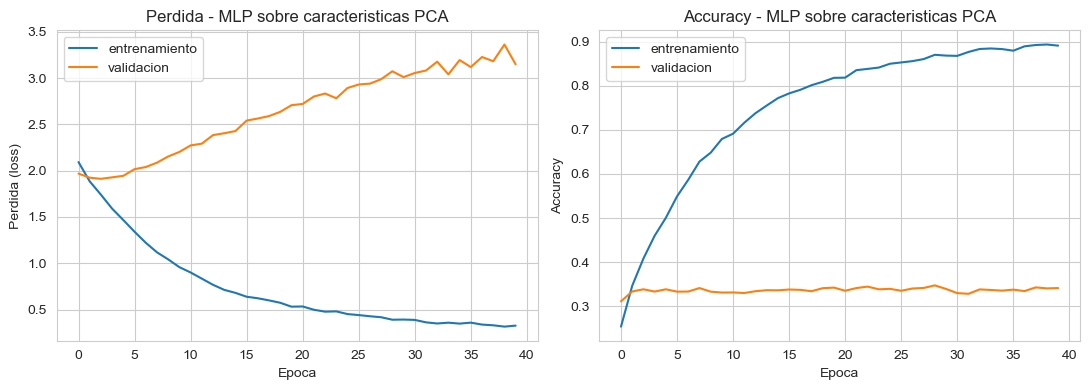

In [22]:
modelo_pca = MLPClasificador(dim_entrada=reductor_pca.dimension_salida, n_clases=N_CLASES,
                              capas_ocultas=(256, 128), dropout=0.3)
entrenador_pca = EntrenadorRedNeuronal(modelo_pca, dispositivo=DISPOSITIVO, lr=1e-3)

inicio = time.time()
historial_pca = entrenador_pca.entrenar(train_loader_pca, val_loader_pca, epocas=40)
print(f"Entrenamiento (PCA) completado en {time.time()-inicio:.1f} s")

entrenador_pca.graficar_curvas(titulo="- MLP sobre caracteristicas PCA")


## 9. Entrenamiento con características extraídas por la CNN preentrenada

Se entrena un segundo `MLPClasificador`, ahora sobre los embeddings de 512 dimensiones extraídos con `ExtractorCNN`. Nótese que el código de entrenamiento es idéntico al de la sección anterior: solo cambian los datos de entrada, gracias a que ambos reductores comparten la misma interfaz.


Epoca   1/40 | train_loss=0.3824 train_acc=0.901 | val_loss=0.0748 val_acc=0.977
Epoca   5/40 | train_loss=0.0418 train_acc=0.985 | val_loss=0.0423 val_acc=0.987
Epoca  10/40 | train_loss=0.0178 train_acc=0.994 | val_loss=0.0470 val_acc=0.987
Epoca  15/40 | train_loss=0.0199 train_acc=0.993 | val_loss=0.0655 val_acc=0.982
Epoca  20/40 | train_loss=0.0052 train_acc=0.999 | val_loss=0.0661 val_acc=0.985
Epoca  25/40 | train_loss=0.0169 train_acc=0.994 | val_loss=0.0711 val_acc=0.982
Epoca  30/40 | train_loss=0.0125 train_acc=0.997 | val_loss=0.0813 val_acc=0.979
Epoca  35/40 | train_loss=0.0121 train_acc=0.996 | val_loss=0.0637 val_acc=0.983
Epoca  40/40 | train_loss=0.0110 train_acc=0.997 | val_loss=0.0744 val_acc=0.983
Entrenamiento (CNN) completado en 14.2 s


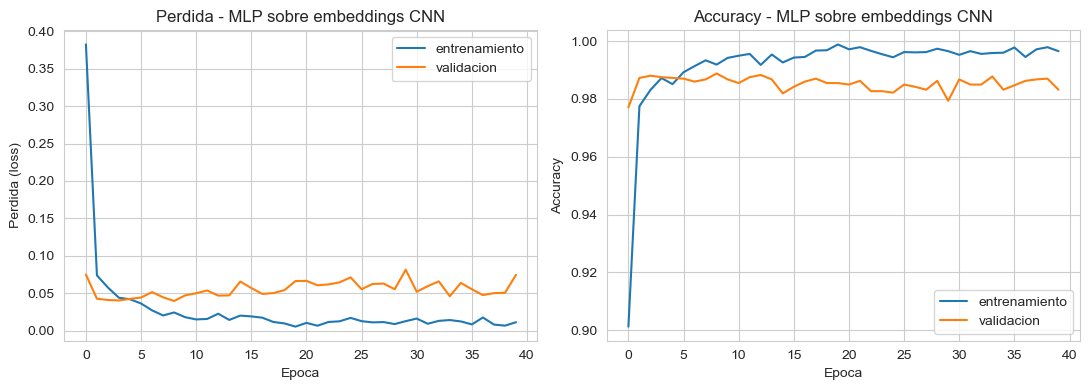

In [23]:
modelo_cnn = MLPClasificador(dim_entrada=extractor_cnn.dimension_salida, n_clases=N_CLASES,
                              capas_ocultas=(256, 64), dropout=0.3)
entrenador_cnn = EntrenadorRedNeuronal(modelo_cnn, dispositivo=DISPOSITIVO, lr=1e-3)

inicio = time.time()
historial_cnn = entrenador_cnn.entrenar(train_loader_cnn, val_loader_cnn, epocas=40)
print(f"Entrenamiento (CNN) completado en {time.time()-inicio:.1f} s")

entrenador_cnn.graficar_curvas(titulo="- MLP sobre embeddings CNN")


## 10. Evaluación y comparación de resultados

Se comparan ambos modelos entrenados con `EvaluadorModelo`: reporte de clasificación, matriz de confusión y una comparación final de exactitud (accuracy) frente a la dimensionalidad de las características usadas por cada uno.


--- MLP + PCA (accuracy = 0.341) ---
                        precision    recall  f1-score   support

                 tenca       0.39      0.39      0.39       387
      springer spaniel       0.30      0.34      0.32       395
reproductor de casetes       0.42      0.52      0.47       357
            motosierra       0.23      0.23      0.23       386
               iglesia       0.33      0.30      0.32       409
                trompa       0.21      0.17      0.19       394
      camion de basura       0.38      0.37      0.38       389
  surtidor de gasolina       0.24      0.25      0.25       419
        pelota de golf       0.37      0.36      0.37       399
            paracaidas       0.55      0.51      0.53       390

              accuracy                           0.34      3925
             macro avg       0.34      0.34      0.34      3925
          weighted avg       0.34      0.34      0.34      3925



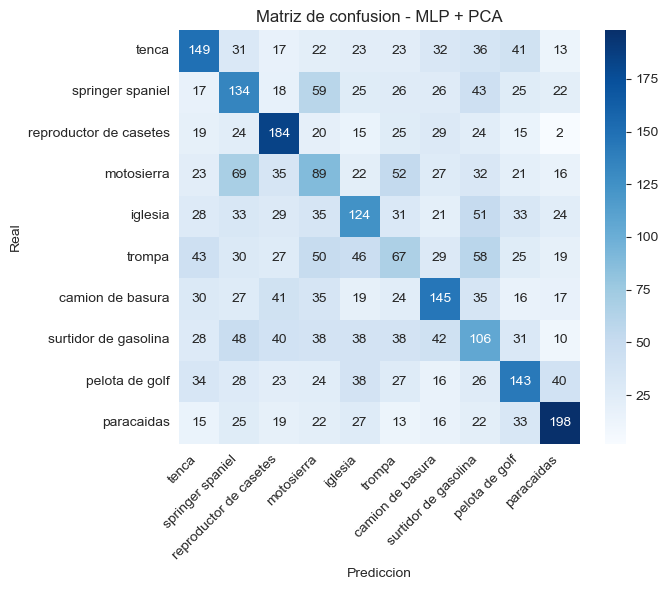

In [24]:
nombres_clases_lista = [IDX_A_NOMBRE[i] for i in range(N_CLASES)]

evaluador_pca = EvaluadorModelo(modelo_pca, dispositivo=DISPOSITIVO)
matriz_pca, acc_pca = evaluador_pca.reporte(val_loader_pca, nombres_clases_lista, titulo="MLP + PCA")
evaluador_pca.graficar_matriz_confusion(matriz_pca, nombres_clases_lista, titulo="- MLP + PCA")


--- MLP + CNN preentrenada (accuracy = 0.983) ---
                        precision    recall  f1-score   support

                 tenca       0.99      1.00      1.00       387
      springer spaniel       1.00      1.00      1.00       395
reproductor de casetes       0.98      0.97      0.98       357
            motosierra       0.98      0.95      0.96       386
               iglesia       0.99      0.99      0.99       409
                trompa       1.00      0.95      0.98       394
      camion de basura       0.97      0.99      0.98       389
  surtidor de gasolina       0.97      0.98      0.97       419
        pelota de golf       0.98      0.99      0.99       399
            paracaidas       0.97      1.00      0.98       390

              accuracy                           0.98      3925
             macro avg       0.98      0.98      0.98      3925
          weighted avg       0.98      0.98      0.98      3925



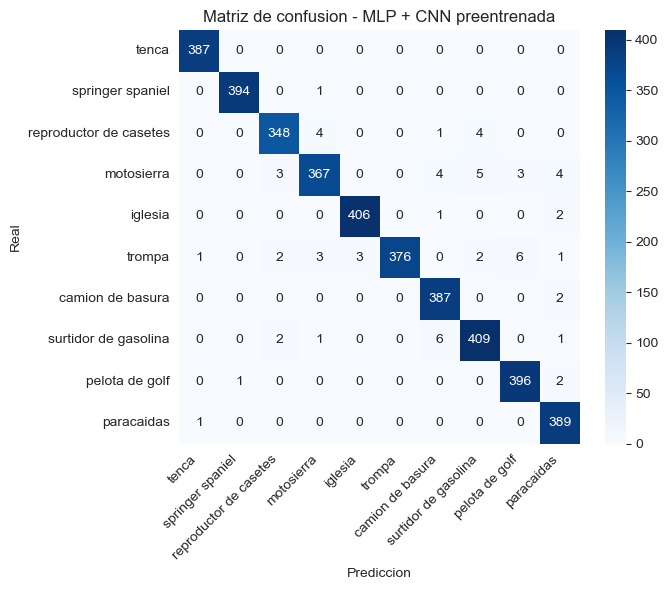

In [25]:
evaluador_cnn = EvaluadorModelo(modelo_cnn, dispositivo=DISPOSITIVO)
matriz_cnn, acc_cnn = evaluador_cnn.reporte(val_loader_cnn, nombres_clases_lista, titulo="MLP + CNN preentrenada")
evaluador_cnn.graficar_matriz_confusion(matriz_cnn, nombres_clases_lista, titulo="- MLP + CNN preentrenada")


,Pipeline,Dimension de entrada,Accuracy (validacion)
0,Vectorizacion + PCA,506,0.341146
1,CNN preentrenada (embeddings),512,0.983185


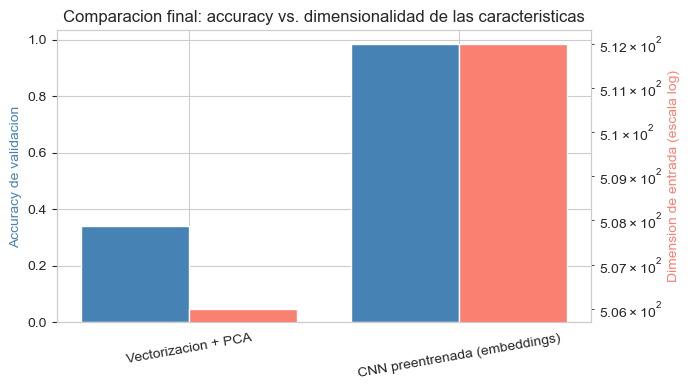

In [26]:
resumen_final = pd.DataFrame([
    {"Pipeline": "Vectorizacion + PCA", "Dimension de entrada": reductor_pca.dimension_salida, "Accuracy (validacion)": acc_pca},
    {"Pipeline": "CNN preentrenada (embeddings)", "Dimension de entrada": extractor_cnn.dimension_salida, "Accuracy (validacion)": acc_cnn},
])
display(resumen_final)

fig, ax1 = plt.subplots(figsize=(7, 4))
ax2 = ax1.twinx()
x_pos = np.arange(len(resumen_final))
ax1.bar(x_pos - 0.2, resumen_final["Accuracy (validacion)"], width=0.4, color="steelblue", label="Accuracy")
ax2.bar(x_pos + 0.2, resumen_final["Dimension de entrada"], width=0.4, color="salmon", label="Dimension de entrada")
ax1.set_xticks(x_pos); ax1.set_xticklabels(resumen_final["Pipeline"], rotation=10)
ax1.set_ylabel("Accuracy de validacion", color="steelblue")
ax2.set_ylabel("Dimension de entrada (escala log)", color="salmon")
ax2.set_yscale("log")
plt.title("Comparacion final: accuracy vs. dimensionalidad de las caracteristicas")
fig.tight_layout()
plt.show()


## 11. Conclusiones

- Vectorizar imágenes de más de 200 px conserva toda la información visual, pero produce vectores de características enormes (120 000 valores para una sola imagen de 200×200 px en color), lo que hace inviable entrenar modelos directamente sobre los píxeles crudos en la práctica (maldición de la dimensionalidad).
- El redimensionamiento y la conversión a escala de grises son formas simples y directas de controlar el tamaño del vector, aunque implican una pérdida de información fija y arbitraria.
- **PCA** reduce la dimensionalidad aprovechando la redundancia estadística entre píxeles, reteniendo un porcentaje configurable de la varianza total con muchas menos dimensiones que el vector original.
- La **extracción de características con una CNN preentrenada** logra una reducción todavía más compacta (512 dimensiones) y, al basarse en patrones visuales aprendidos en lugar de en correlaciones de píxeles crudos, típicamente conserva mayor poder discriminativo para la tarea de clasificación.
- Diseñar el pipeline mediante **clases con una interfaz común** (`ReductorDimensionalidad`) permitió reutilizar exactamente el mismo código de entrenamiento (`EntrenadorRedNeuronal`) y evaluación (`EvaluadorModelo`) para ambos métodos de reducción, cambiando únicamente el reductor utilizado.

**Posibles extensiones:** afinar (fine-tuning) las últimas capas de la CNN en lugar de usarla solo como extractor fijo, aplicar aumento de datos (data augmentation), probar otras arquitecturas preentrenadas (ResNet-34, EfficientNet), o incorporar una parada temprana (*early stopping*) basada en la pérdida de validación.
